In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os
from langchain_openai import ChatOpenAI

In [16]:
from dotenv import load_dotenv
load_dotenv()

model = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.5)

In [17]:
class BlogState(TypedDict):
    topic : str
    outline : str
    final_blog : str

In [18]:
def generate_outline(state: BlogState)-> BlogState:
    topic = state['topic']
    prompt = f"Generate a detailed outline for a blog post on the topic: {topic}"
    outline = model.invoke(prompt)
    state['outline'] = outline
    return state

def generate_final_blog(state: BlogState)-> BlogState:
    topic = state['topic']
    outline = state['outline']
    prompt = f"Using the following outline, write a comprehensive blog post on the topic: {topic}\n\nOutline:\n{outline}"
    final_blog = model.invoke(prompt)
    state['final_blog'] = final_blog
    return state

In [19]:
graph = StateGraph(BlogState)
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_final_blog', generate_final_blog)

graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_final_blog')
graph.add_edge('generate_final_blog', END)

workflow = graph.compile()

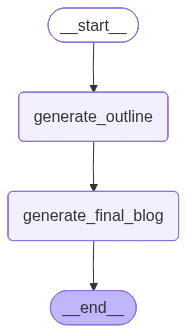

In [20]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [21]:
input_state = {"topic" : "The Future of Artificial Intelligence"}
output_state = workflow.invoke(input_state)
print(output_state)

{'topic': 'The Future of Artificial Intelligence', 'outline': AIMessage(content="# Blog Post Outline: The Future of Artificial Intelligence\n\n## Introduction\n- Brief overview of artificial intelligence (AI) and its significance in today's world.\n- Importance of discussing the future of AI: implications for society, economy, and technology.\n- Purpose of the blog post: to explore trends, predictions, and potential challenges in the future of AI.\n\n## Section 1: Current State of Artificial Intelligence\n- Overview of AI technologies in use today (e.g., machine learning, natural language processing, computer vision).\n- Key industries utilizing AI (healthcare, finance, transportation, etc.).\n- Recent advancements and breakthroughs in AI (e.g., GPT-4, advancements in robotics).\n\n## Section 2: Emerging Trends in AI\n- **Trend 1: Increased Automation**\n  - Explanation of how AI is automating tasks across various sectors.\n  - Examples of automation in manufacturing, customer service,

In [22]:
print(output_state['outline'])
print(output_state['final_blog'])

content="# Blog Post Outline: The Future of Artificial Intelligence\n\n## Introduction\n- Brief overview of artificial intelligence (AI) and its significance in today's world.\n- Importance of discussing the future of AI: implications for society, economy, and technology.\n- Purpose of the blog post: to explore trends, predictions, and potential challenges in the future of AI.\n\n## Section 1: Current State of Artificial Intelligence\n- Overview of AI technologies in use today (e.g., machine learning, natural language processing, computer vision).\n- Key industries utilizing AI (healthcare, finance, transportation, etc.).\n- Recent advancements and breakthroughs in AI (e.g., GPT-4, advancements in robotics).\n\n## Section 2: Emerging Trends in AI\n- **Trend 1: Increased Automation**\n  - Explanation of how AI is automating tasks across various sectors.\n  - Examples of automation in manufacturing, customer service, and logistics.\n  \n- **Trend 2: AI Ethics and Regulation**\n  - Discus

In [23]:
print("outline:")
print(output_state['outline'].content)

print("-" * 350) # separator line

print("final_blog:")
print(output_state['final_blog'].content)

outline:
# Blog Post Outline: The Future of Artificial Intelligence

## Introduction
- Brief overview of artificial intelligence (AI) and its significance in today's world.
- Importance of discussing the future of AI: implications for society, economy, and technology.
- Purpose of the blog post: to explore trends, predictions, and potential challenges in the future of AI.

## Section 1: Current State of Artificial Intelligence
- Overview of AI technologies in use today (e.g., machine learning, natural language processing, computer vision).
- Key industries utilizing AI (healthcare, finance, transportation, etc.).
- Recent advancements and breakthroughs in AI (e.g., GPT-4, advancements in robotics).

## Section 2: Emerging Trends in AI
- **Trend 1: Increased Automation**
  - Explanation of how AI is automating tasks across various sectors.
  - Examples of automation in manufacturing, customer service, and logistics.
  
- **Trend 2: AI Ethics and Regulation**
  - Discussion on the growin